**🎯Goal**

Find why customers leave, who leaves most, and what the company can do to reduce churn.

**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


**2. Load Dataset**

In [3]:
import pandas as pd
from google.colab import files
import os

file_name = "Sample-Telco Customer Churn dataset(project 4).csv"

# Check if the file exists. If not, prompt the user to upload it.
if not os.path.exists(file_name):
  print(f"The file '{file_name}' was not found. Please upload it.")
  uploaded = files.upload() # This will open a file upload dialog in the browser
  if file_name not in uploaded:
    print(f"File '{file_name}' was not uploaded. Please try again.")
  else:
    print(f"File '{file_name}' uploaded successfully.")

# Now try to read the CSV. If the user uploaded it, this should work.
df = pd.read_csv(file_name)
df

The file 'Sample-Telco Customer Churn dataset(project 4).csv' was not found. Please upload it.


Saving Sample-Telco Customer Churn dataset(project 4).csv to Sample-Telco Customer Churn dataset(project 4).csv
File 'Sample-Telco Customer Churn dataset(project 4).csv' uploaded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**3. Basic Exploration**

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**4. Basic Understanding of Data**

In [6]:
print("Shape:", df.shape)
df.head()
df.info()
df.describe()
df.isnull().sum()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**5. Data Cleaning**

(a)Convert TotalCharges to numeric

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipython-input-551351825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


(b)Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

(c)Fix Categorical Formatting

In [9]:
df.columns = df.columns.str.replace(" ", "_")   # replaces spaces with underscores

df["Churn"] = df["Churn"].apply(lambda x: 1 if x=="Yes" else 0)

(d)Check Again

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**6. 📊Exploratory Data Analysis**

(a)Churn Count(Distribution)

/tmp/ipython-input-821916363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="coolwarm")


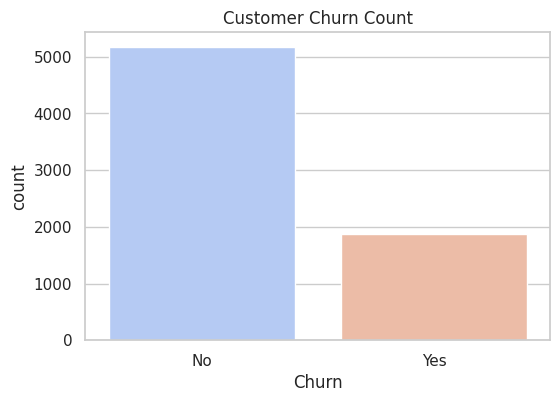

,proportion
Churn,
0,73.463013
1,26.536987


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="coolwarm")
plt.title("Customer Churn Count")
plt.xticks([0,1], ["No", "Yes"])
plt.show()

df["Churn"].value_counts(normalize=True)*100

(b)Gender vs Churn

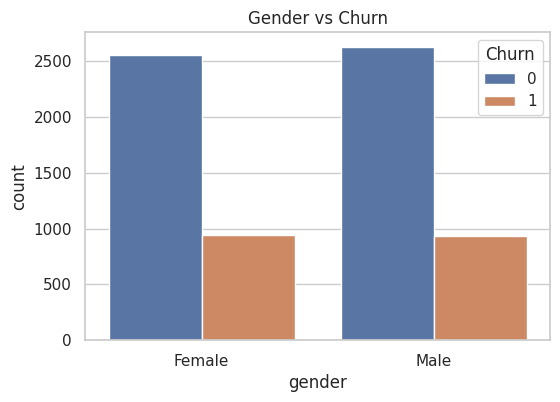

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

(c)Contract Type vs Churn

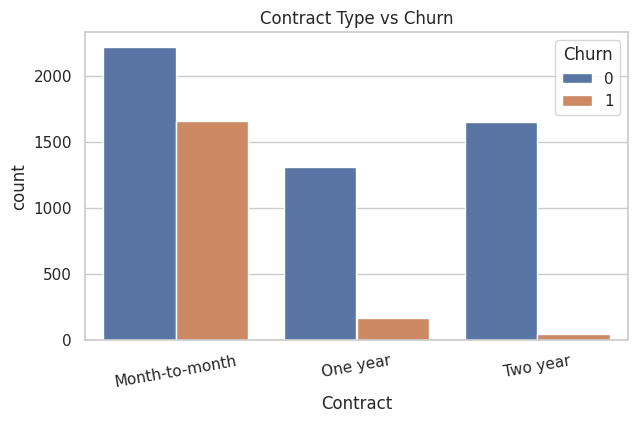

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.show()

(d)Tenure vs Churn

Create Tenure Groups:

In [14]:
bins = [0, 12, 24, 48, 72]
labels = ['0-1 yr','1-2 yrs','2-4 yrs','4-6 yrs']
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

Plot:

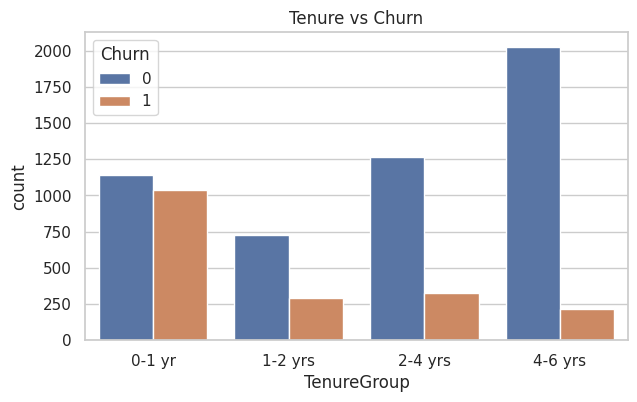

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(x="TenureGroup", hue="Churn", data=df)
plt.title("Tenure vs Churn")
plt.show()

(e)Monthly Charges vs Churn

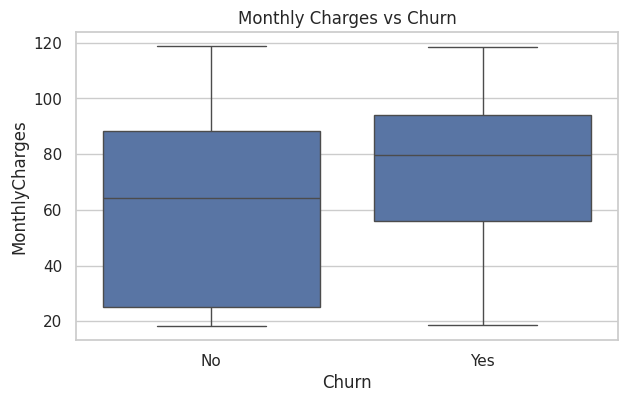

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.xticks([0,1], ["No","Yes"])
plt.show()

(f)Internet Service vs Churn

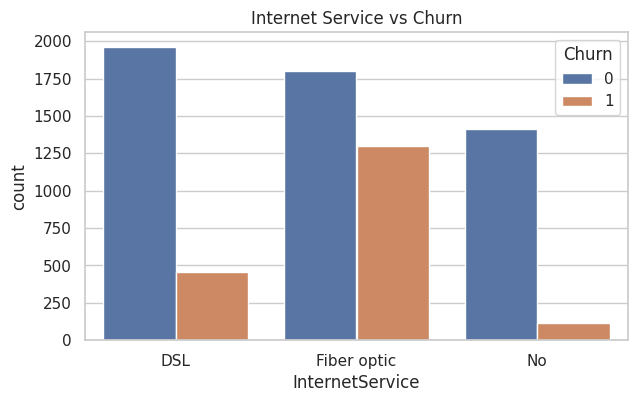

In [17]:
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

**7. Key Insights**

• Customers with Month-to-Month contracts churn the most

• Low tenure customers are highly likely to leave

• Higher Monthly Charges customers churn more

• Fiber optic internet users churn more than DSL

• Gender has no big effect on churn


**8. Business Recomendations**

1️⃣ Convert Month-to-Month users → Yearly plans

2️⃣ Provide discounts to new customers (< 1 year)

3️⃣ Create low-price plans to reduce bill shock

4️⃣ Improve Fiber Internet service quality

5️⃣ Loyalty rewards for long-tenure customers

**END**